# Урок 01. Векторы и операции над ними

> **Зачем это нужно:** любые данные в ML — это векторы. Картинка 28×28 — вектор из 784 чисел. Пользователь — вектор предпочтений. Слово — вектор эмбеддинга.

---

## 1. Что такое вектор

В ML вектор — это просто упорядоченный набор чисел.

```
x = [3.0, -1.5, 2.7, 0.0, 5.1]   # вектор размерности 5
```

Размерность вектора — количество чисел в нём. В реальных задачах размерности от 2 (точка на плоскости) до 4096 (эмбеддинг от BERT) и больше.


In [5]:
import numpy as np

v = np.array([3, -1.5, 2.7, 0.0, 5.1])
print(v.shape)
print(v.ndim)

v_range = np.arange(1, 10)
v_zeros = np.zeros(5)
v_ones = np.ones(5)

print(v_range)
print(v_zeros)
print(v_ones)

(5,)
1
[1 2 3 4 5 6 7 8 9]
[0. 0. 0. 0. 0.]
[1. 1. 1. 1. 1.]


## 2. Сложение и умножение на скаляр

**Сложение векторов** — поэлементно. Размерности должны совпадать.

$$ a + b = (a_1 + b_1, a_2 + b_2, \dots, a_n + b_n) $$

**Умножение на скаляр** — каждый элемент умножается на число.

$$ \alpha \cdot a = (\alpha a_1, \alpha a_2, \dots, \alpha a_n) $$

In [7]:
a = np.array([1, 2, 3])
b = np.array([3, 2, 1])
print(a + b)
print(2 * a)
print(a - b)

[4 4 4]
[2 4 6]
[-2  0  2]


**Интуиция:** сложение — это «склейка» движений. Если `a` — это «шаг на восток на 3 метра», а `b` — «шаг на север на 4 метра», то `a + b` — это диагональный шаг.


## 3. Скалярное произведение (dot product)


$$ a \cdot b = \sum_{i=1}^{n} a_i b_i = a_1 b_1 + a_2 b_2 + \dots + a_n b_n $$

Результат — **одно число** (скаляр).

In [9]:
a = np.array([1, 2, 3])
b = np.array([1, 2, 3])

print(np.dot(a, b))
print(a @ b)
print((a * b).sum())

14
14
14


**В ML:**
- Один нейрон вычисляет `w · x + b` — это скалярное произведение весов и входа.
- В attention считаем `Q · K` — близость запроса к каждому ключу.
- В рекомендательных системах `user · item` даёт оценку.

## 4. Норма вектора (длина)

**Евклидова норма (L2) - длина вектора:**

$$ \|a\|_2 = \sqrt{a_1^2 + a_2^2 + \dots + a_n^2} = \sqrt{a \cdot a} $$

In [20]:
a = np.array([3, 4])

# По умолчанию ord=2 (L2-норма)
l2_norm = np.linalg.norm(a)

print(l2_norm)
print(np.sqrt(a @ a))

5.0
5.0


**L1 норма** — сумма модулей (Манхэттенская длина):

$$ \|a\|_1 = |a_1| + |a_2| + \dots + |a_n| $$

In [21]:
print(np.linalg.norm(a, ord=1))

7.0


L1 даёт разреженные решения (Lasso), L2 — гладкие (Ridge).

## 5. Косинус угла между векторами

Самая частая метрика "похожести" в ML:

$$ \cos(\theta) = \frac{a \cdot b}{\|a\| \cdot \|b\|} $$

Значение от -1 до 1. Близко к 1 — векторы «смотрят в одну сторону», 0 — перпендикулярны, -1 — противоположны.


In [35]:
def cosine(a, b):
    return (a @ b) / ((np.linalg.norm(a)) * (np.linalg.norm(b)))

a = np.array([1, 2, 3])
b = np.array([1, 2, 3])
ans = cosine(a, b)

print(ans)

1.0


**В ML:** поиск похожих документов, рекомендации, семантический поиск, кластеризация эмбеддингов.


## 6. Практические задания


1. **Реализуйте функцию `norm(v, p)`** — Lp-норма вектора (без `np.linalg`). Проверьте на p=1, 2, ∞.


# Нормы векторов ($L_1, L_2, L_\infty$)

**Норма вектора** — это математическая функция, которая определяет геометрическую длину вектора или величину его элементов.

---

### 1. Манхэттенская норма ($L_1$)
* **Формула**: $\|v\|_1 = \sum |x_i|$
* **Суть**: Сумма абсолютных значений (модулей) всех компонентов вектора.
* **В ML (Lasso)**: Обнуляет коэффициенты слабых признаков. Используется для автоматического отбора наиболее важных параметров (**разреженные решения**).
* **Геометрия**: Множество точек с нормой равной 1 образует **ромб**.

### 2. Евклидова норма ($L_2$)
* **Формула**: $\|v\|_2 = \sqrt{\sum x_i^2}$
* **Суть**: Квадратный корень из суммы квадратов всех компонентов. Стандартная физическая длина вектора по прямой.
* **В ML (Ridge)**: Равномерно уменьшает все веса модели до близких к нулю значений, но не зануляет их полностью (**гладкие решения**). Помогает бороться с мультиколлинеарностью.
* **Геометрия**: Множество точек с нормой равной 1 образует **круг**.

### 3. Максимальная норма Чебышёва ($L_\infty$)
* **Формула**: $\|v\|_\infty = \max(|x_i|)$
* **Суть**: Равна максимальному абсолютному значению среди всех элементов вектора.
* **Математический смысл**: При устремлении степени $p \to \infty$ в общей формуле $L_p$, самый большой элемент начинает расти колоссально быстрее остальных. При извлечении корня степени $p$ влияние мелких элементов сводится к нулю, оставляя только максимум:
  $$\lim_{p \to \infty} (|x_1|^p + |x_2|^p + \dots + |x_n|^p)^{1/p} = \max(|x_i|)$$
* **Геометрия**: Множество точек с нормой равной 1 образует **квадрат**.



In [36]:
def norm(v, p):
    abs_v = [abs(x) for x in v]

    if p == 'inf' or p == float('inf'):
        return max(abs_v)

    if p < 1:
        return ValueError("Параметр p должен быть больше или равен 1")

    sum_val = sum(x ** p for x in abs_v)
    return sum_val ** (1 / p)

vec = np.array([3, -4, 5])
print(vec)
print(f"p = 1: {norm(vec, 1)}")
print(f"p = 2: {norm(vec, 2):.4f}")
print(f"p = inf: {norm(vec, 'inf')}")

[ 3 -4  5]
p = 1: 12.0
p = 2: 7.0711
p = inf: 5


2. **Косинус без np.** Реализуйте косинусное расстояние, используя только `math.sqrt` и циклы. Сравните с NumPy-версией на 10 случайных парах.


In [38]:
import math
import random

def cosine_distance_pure(a, b):
    dot_product = 0.0
    norm_a_sq = 0.0
    norm_b_sq = 0.0
    
    for x, y in zip(a, b):
        dot_product += x * y
        norm_a_sq += x * x
        norm_b_sq += y * y
        
    if norm_a_sq == 0 or norm_b_sq == 0:
        return 1.0 
        
    cos_sim = dot_product / (math.sqrt(norm_a_sq) * math.sqrt(norm_b_sq))
    return 1.0 - cos_sim


random.seed(42)
dim = 5

print(f"{'Пара':<6} | {'Без numpy':<15} | {'Версия NumPy':<15} | {'Разница':<12}")
print("-" * 57)

for i in range(1, 11):
    a = np.array([random.uniform(-10, 10) for _ in range(dim)])
    b = np.array([random.uniform(-10, 10) for _ in range(dim)])

    dist_pure = cosine_distance_pure(a, b)
    dist_np = 1.0 - cosine(a, b)
    difference = abs(dist_pure - dist_np)

    print(f"#{i:<4} | {dist_pure:<15.6f} | {dist_np:<15.6f} | {difference:.2e}")



Пара   | Без numpy       | Версия NumPy    | Разница     
---------------------------------------------------------
#1    | 1.316866        | 1.316866        | 0.00e+00
#2    | 1.529841        | 1.529841        | 0.00e+00
#3    | 1.284833        | 1.284833        | 0.00e+00
#4    | 0.190879        | 0.190879        | 0.00e+00
#5    | 0.481034        | 0.481034        | 0.00e+00
#6    | 1.411533        | 1.411533        | 0.00e+00
#7    | 1.099292        | 1.099292        | 0.00e+00
#8    | 0.469804        | 0.469804        | 0.00e+00
#9    | 1.620174        | 1.620174        | 0.00e+00
#10   | 1.144989        | 1.144989        | 0.00e+00


3. **Топ-5 похожих слов.** Загрузите готовые word-эмбеддинги (например, [GloVe 50d](https://nlp.stanford.edu/projects/glove/)). Для слова `king` найдите 5 ближайших по косинусу.


Word-эмбеддинги (Word Embeddings) — это способ представления слов в виде плотных векторов из вещественных чисел, где близкие по смыслу слова имеют похожие координаты

In [41]:
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-50")

word = 'king'
top_5 = model.most_similar(word, topn=5) # [('prince', 0.823), ('queen', 0.783), ...].

print(top_5)


[('prince', 0.8236179351806641), ('queen', 0.7839043140411377), ('ii', 0.7746230363845825), ('emperor', 0.7736247777938843), ('son', 0.766719400882721)]


4. **Король − мужчина + женщина = ?** Проверьте классическое равенство на эмбеддингах. Должно выйти что-то близкое к `queen`.


In [43]:
result = model.most_similar(positive=['king', 'woman'], negative=['man'], topn=3)
print(result)

[('queen', 0.8523604273796082), ('throne', 0.7664334177970886), ('prince', 0.7592144012451172)]


5. **Нормализация.** Напишите функцию `normalize(v)`, возвращающую единичный вектор того же направления. Что произойдёт, если подать нулевой вектор?


In [ ]:
def normalize(v):
    # l2_norm = math.sqrt(sum(x ** 2 for x in v))
    l2_norm = np.linalg.norm(v)

    if l2_norm == 0:
        return v
    
    v_normalized = v / l2_norm
    return v_normalized

vec = np.array([3, 4])
vec_zero = np.zeros(5)
print(normalize(vec))
print(normalize(vec_zero))

[0.6 0.8]
[0. 0. 0. 0. 0.]


6. **Проекция.** Реализуйте проекцию вектора `a` на `b`: $\text{proj}_b a = \frac{a \cdot b}{b \cdot b} b$. Визуализируйте на 2D через matplotlib.


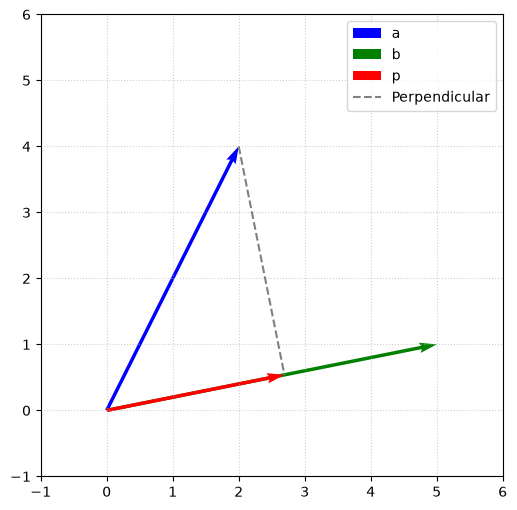

In [49]:
import matplotlib.pyplot as plt

def proj(a, b):
    num = a @ b
    denum = b @ b
    vec = (num / denum) * b
    return vec


a = np.array([2, 4])
b = np.array([5, 1])
p = proj(a, b)

fig, axes = plt.subplots(figsize=(6, 6))

axes.quiver(0, 0, a[0], a[1], angles='xy', scale_units='xy', scale=1, color='blue', label='a')
axes.quiver(0, 0, b[0], b[1], angles='xy', scale_units='xy', scale=1, color='green', label='b')
axes.quiver(0, 0, p[0], p[1], angles='xy', scale_units='xy', scale=1, color='red', label='p')

axes.plot([a[0], p[0]], [a[1], p[1]], color='gray', linestyle='--', label='Perpendicular')

max_val = max(max(a), max(b), 0) + 1
min_val = min(min(a), min(b), 0) - 1

axes.set_xlim(min_val, max_val)
axes.set_ylim(min_val, max_val)
axes.set_aspect('equal')

axes.grid(True, linestyle=':', alpha=0.6)
axes.legend()

plt.show()




7. **Угол между документами.** Возьмите 5 коротких текстов. Постройте bag-of-words векторы. Посчитайте попарные косинусные близости. Какие документы оказались похожими?

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

texts = [
    "Кот спит на теплом коврике",
    "Пушистый кот громко мурчит",
    "Ракета летит на далекую марсианскую станцию",
    "Космический корабль вышел на орбиту планеты",
    "Мой маленький кот любит играть"
]

# Создание словаря, приведение всех текстов к нижнему регистру и сортировка по алфавиту
# Текст -> вектор (координаты вектора = количество повторений слова в тексте)
vectorizer = CountVectorizer() 

# обучение на текстах и трансформация в массив векторов
bow_matrix = vectorizer.fit_transform(texts).toarray()

cosine_matrix = cosine_similarity(bow_matrix)

df_matrix = pd.DataFrame(
    cosine_matrix, 
    index=[f"Документ {i+1}" for i in range(5)], 
    columns=[f"Документ {i+1}" for i in range(5)]
)
print(df_matrix.round(3))


# ВТОРОЕ РЕШЕНИЕ (несовершенный)
def tokenize(text):
    return text.lower().split()

vocab = set()
for text in texts:
    for word in tokenize(text):
        vocab.add(word)
vocab = sorted(list(vocab))

# Функция создания Bag-of-Words вектора
def text_to_bow(text, vocabulary):
    words = tokenize(text)
    return [words.count(word) for word in vocabulary]

# Строим векторы для всех текстов
bow_vectors = [text_to_bow(t, vocab) for t in texts]

def dot_product(v1, v2):
    return sum(x * y for x, y in zip(v1, v2))

def vector_norm(v):
    return math.sqrt(sum(x * x for x in v))

def cosine_similarity(v1, v2):
    norm1 = vector_norm(v1)
    norm2 = vector_norm(v2)
    if norm1 == 0 or norm2 == 0:
        return 0.0
    return dot_product(v1, v2) / (norm1 * norm2)

# Считаем попарную близость и выводим результат
print()
print("Попарная косинусная близость текстов:")
for i in range(len(texts)):
    for j in range(len(texts)):
        sim = cosine_similarity(bow_vectors[i], bow_vectors[j])
        print(f"Текст {i+1} <-> Текст {j+1}: {sim:.3f}")
    print("-" * 30)


            Документ 1  Документ 2  Документ 3  Документ 4  Документ 5
Документ 1       1.000       0.224       0.183       0.183       0.200
Документ 2       0.224       1.000       0.000       0.000       0.224
Документ 3       0.183       0.000       1.000       0.167       0.000
Документ 4       0.183       0.000       0.167       1.000       0.000
Документ 5       0.200       0.224       0.000       0.000       1.000

Попарная косинусная близость текстов:
Текст 1 <-> Текст 1: 1.000
Текст 1 <-> Текст 2: 0.224
Текст 1 <-> Текст 3: 0.183
Текст 1 <-> Текст 4: 0.183
Текст 1 <-> Текст 5: 0.200
------------------------------
Текст 2 <-> Текст 1: 0.224
Текст 2 <-> Текст 2: 1.000
Текст 2 <-> Текст 3: 0.000
Текст 2 <-> Текст 4: 0.000
Текст 2 <-> Текст 5: 0.224
------------------------------
Текст 3 <-> Текст 1: 0.183
Текст 3 <-> Текст 2: 0.000
Текст 3 <-> Текст 3: 1.000
Текст 3 <-> Текст 4: 0.167
Текст 3 <-> Текст 5: 0.000
------------------------------
Текст 4 <-> Текст 1: 0.183
Текст 4 <-

8. **Перпендикулярность.** Сгенерируйте случайный вектор в R^100. Найдите хотя бы один ненулевой вектор, перпендикулярный ему (скалярное произведение = 0).


In [67]:
random.seed(42)
a = np.array([random.uniform(-10, 10) for _ in range(100)])

b = np.zeros(100)
b[0] = -a[1]
b[1] = a[0]
dot_prod = sum(x * y for x, y in zip(a, b))
print(dot_prod == 0.0)

c = np.array([random.uniform(-10, 10) for _ in range(99)])
last_coeff = - sum(x * y for x, y in zip(a[:99], c)) / a[99]
new_c = np.append(c, last_coeff)
dot_prod_second = sum(x * y for x, y in zip(a, new_c))
print(dot_prod_second == 0.0)


True
True
